In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset DoS
df_dos = pd.read_csv('DoS_dataset.csv', header=None)

# Voir le nombre de colonnes et les premières lignes
print("Nombre de colonnes:", df_dos.shape[1])
print("Shape:", df_dos.shape)
df_dos.head(10)

Nombre de colonnes: 12
Shape: (3665771, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.478198e+09,0316,8,05,21,68,09,21,21,00,6f,R
1,1.478198e+09,018f,8,fe,5b,00,00,00,3c,00,00,R
2,1.478198e+09,0260,8,19,21,22,30,08,8e,6d,3a,R
3,1.478198e+09,02a0,8,64,00,9a,1d,97,02,bd,00,R
4,1.478198e+09,0329,8,40,bb,7f,14,11,20,00,14,R
5,1.478198e+09,0545,8,d8,00,00,8a,00,00,00,00,R
6,1.478198e+09,0002,8,00,00,00,00,00,03,0b,11,R
7,1.478198e+09,0153,8,00,21,10,ff,00,ff,00,00,R
8,1.478198e+09,02c0,8,14,00,00,00,00,00,00,00,R
9,1.478198e+09,0130,8,08,80,00,ff,31,80,0b,7f,R


Distribution des flags:
Flag
R    3047062
T     587521
Name: count, dtype: int64


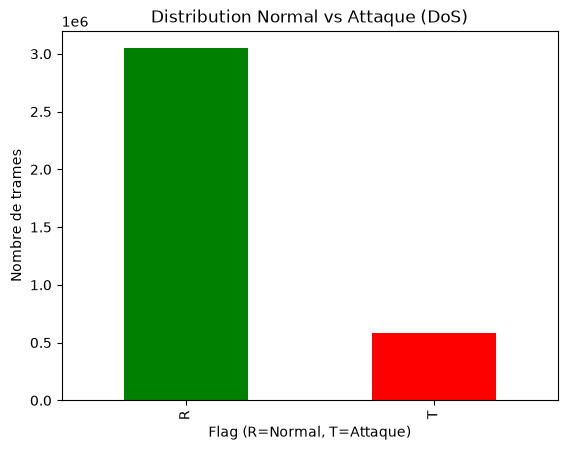

In [4]:
# Renommer les colonnes correctement
df_dos.columns = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

# Voir la distribution des classes (normal vs attaque)
print("Distribution des flags:")
print(df_dos['Flag'].value_counts())

# Visualiser
df_dos['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (DoS)')
plt.xlabel('Flag (R=Normal, T=Attaque)')
plt.ylabel('Nombre de trames')
plt.show()

In [5]:
# Voir les IDs les plus fréquents dans les attaques
attaques = df_dos[df_dos['Flag'] == 'T']
normales = df_dos[df_dos['Flag'] == 'R']

print("Top 10 IDs dans les attaques DoS:")
print(attaques['ID'].value_counts().head(10))

print("\nTop 10 IDs normaux:")
print(normales['ID'].value_counts().head(10))

Top 10 IDs dans les attaques DoS:
ID
0000    587521
Name: count, dtype: int64

Top 10 IDs normaux:
ID
0130    168118
0002    167556
0131    167016
0140    167002
018f    166931
02c0    166713
0370    166681
0316    166631
0153    166573
043f    166103
Name: count, dtype: int64


Rapport de classification:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00   3047062
           T       1.00      1.00      1.00    587521

    accuracy                           1.00   3634583
   macro avg       1.00      1.00      1.00   3634583
weighted avg       1.00      1.00      1.00   3634583



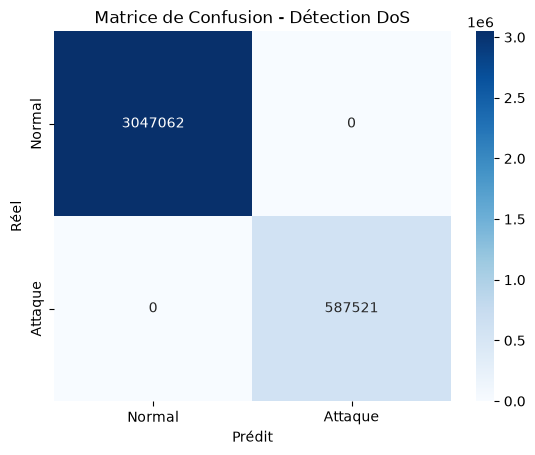

In [7]:
# Nettoyer les données
df_dos = df_dos.dropna(subset=['Flag'])
df_dos['Flag'] = df_dos['Flag'].str.strip()

# Règle de détection simple
df_dos['Prediction'] = df_dos['ID'].apply(lambda x: 'T' if str(x).strip() == '0000' else 'R')

# Évaluer la précision
from sklearn.metrics import classification_report, confusion_matrix

print("Rapport de classification:")
print(classification_report(df_dos['Flag'], df_dos['Prediction']))

# Matrice de confusion
cm = confusion_matrix(df_dos['Flag'], df_dos['Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection DoS')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

In [8]:
# Charger le dataset Fuzzy
df_fuzzy = pd.read_csv('Fuzzy_dataset.csv', header=None)
df_fuzzy.columns = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

# Nettoyer
df_fuzzy = df_fuzzy.dropna(subset=['Flag'])
df_fuzzy['Flag'] = df_fuzzy['Flag'].str.strip()

# Distribution
print("Distribution des flags:")
print(df_fuzzy['Flag'].value_counts())

print("\nTop 10 IDs dans les attaques Fuzzy:")
print(df_fuzzy[df_fuzzy['Flag'] == 'T']['ID'].value_counts().head(10))

# Visualiser
df_fuzzy['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (Fuzzy)')
plt.xlabel('Flag')
plt.ylabel('Nombre de trames')
plt.show()

ParserError: Error tokenizing data. C error: Expected 9 fields in line 65538, saw 12


/var/folders/x3/q795jdbj25z2m082hx6tj3y00000gn/T/ipykernel_91792/2984137162.py:2: DtypeWarning: Columns (0: 6, 1: 9, 2: 11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fuzzy = pd.read_csv('Fuzzy_dataset.csv', header=None, on_bad_lines='skip')


Shape: (2032772, 12)

Distribution des flags:
Flag
R    1813020
T     156085
Name: count, dtype: int64


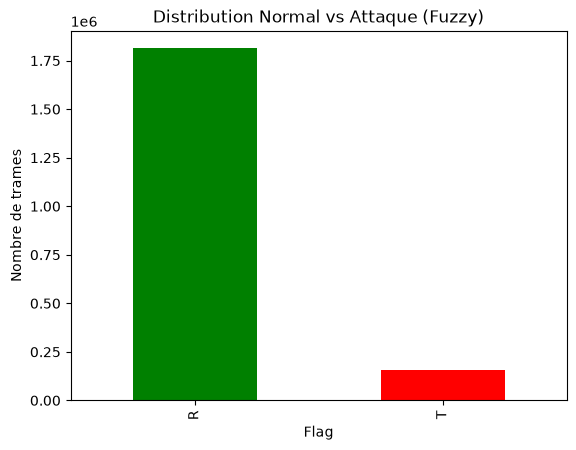

In [9]:
# Charger le dataset Fuzzy avec gestion d'erreurs
df_fuzzy = pd.read_csv('Fuzzy_dataset.csv', header=None, on_bad_lines='skip')
df_fuzzy.columns = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

# Nettoyer
df_fuzzy = df_fuzzy.dropna(subset=['Flag'])
df_fuzzy['Flag'] = df_fuzzy['Flag'].str.strip()

# Distribution
print("Shape:", df_fuzzy.shape)
print("\nDistribution des flags:")
print(df_fuzzy['Flag'].value_counts())

# Visualiser
df_fuzzy['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (Fuzzy)')
plt.xlabel('Flag')
plt.ylabel('Nombre de trames')
plt.show()

In [10]:
# Voir les IDs dans les attaques Fuzzy
print("Top 10 IDs dans les attaques Fuzzy:")
print(df_fuzzy[df_fuzzy['Flag'] == 'T']['ID'].value_counts().head(10))

print("\nTop 10 IDs normaux:")
print(df_fuzzy[df_fuzzy['Flag'] == 'R']['ID'].value_counts().head(10))

Top 10 IDs dans les attaques Fuzzy:
ID
02b8    104
07f1    103
06e8    102
0269    102
0088    101
0186    101
025b    101
0603    100
023f    100
0708    100
Name: count, dtype: int64

Top 10 IDs normaux:
ID
0316    100816
02c0     99784
043f     99763
0002     99733
018f     99474
0350     99328
0130     98872
0260     98851
0153     98778
0370     98725
Name: count, dtype: int64


In [11]:
# Collecter les IDs normaux connus
ids_normaux = set(df_fuzzy[df_fuzzy['Flag'] == 'R']['ID'].unique())
print("Nombre d'IDs normaux connus:", len(ids_normaux))

# Règle : si l'ID n'est pas dans les IDs normaux → attaque
df_fuzzy['Prediction'] = df_fuzzy['ID'].apply(
    lambda x: 'T' if x not in ids_normaux else 'R'
)

# Évaluer
print("\nRapport de classification:")
print(classification_report(df_fuzzy['Flag'], df_fuzzy['Prediction']))

Nombre d'IDs normaux connus: 33

Rapport de classification:


TypeError: '<' not supported between instances of 'float' and 'str'

Rapport de classification:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00   1813020
           T       1.00      0.98      0.99    156085

    accuracy                           1.00   1969105
   macro avg       1.00      0.99      1.00   1969105
weighted avg       1.00      1.00      1.00   1969105



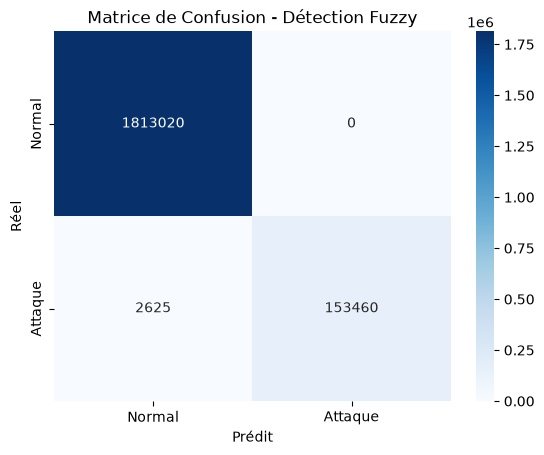

In [12]:
# Nettoyer les deux colonnes
df_fuzzy['Flag'] = df_fuzzy['Flag'].astype(str).str.strip()
df_fuzzy['Prediction'] = df_fuzzy['Prediction'].astype(str).str.strip()
df_fuzzy = df_fuzzy[df_fuzzy['Flag'].isin(['R', 'T'])]
df_fuzzy = df_fuzzy[df_fuzzy['Prediction'].isin(['R', 'T'])]

# Évaluer
print("Rapport de classification:")
print(classification_report(df_fuzzy['Flag'], df_fuzzy['Prediction']))

# Matrice de confusion
cm = confusion_matrix(df_fuzzy['Flag'], df_fuzzy['Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection Fuzzy')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

Shape: (4580226, 12)

Distribution des flags:
Flag
R    3925329
T     654897
Name: count, dtype: int64


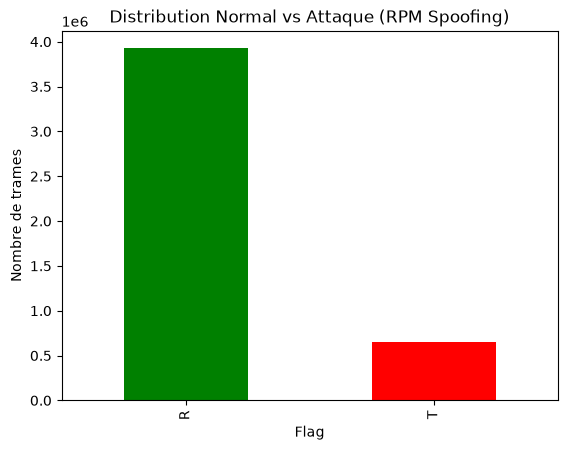

In [13]:
# Charger le dataset RPM
df_rpm = pd.read_csv('RPM_dataset.csv', header=None, on_bad_lines='skip')
df_rpm.columns = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

# Nettoyer
df_rpm = df_rpm.dropna(subset=['Flag'])
df_rpm['Flag'] = df_rpm['Flag'].str.strip()

# Distribution
print("Shape:", df_rpm.shape)
print("\nDistribution des flags:")
print(df_rpm['Flag'].value_counts())

# Visualiser
df_rpm['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (RPM Spoofing)')
plt.xlabel('Flag')
plt.ylabel('Nombre de trames')
plt.show()

In [14]:
# Voir les IDs dans les attaques RPM
print("Top 10 IDs dans les attaques RPM:")
print(df_rpm[df_rpm['Flag'] == 'T']['ID'].value_counts().head(10))

print("\nTop 10 IDs normaux:")
print(df_rpm[df_rpm['Flag'] == 'R']['ID'].value_counts().head(10))

Top 10 IDs dans les attaques RPM:
ID
0316    654897
Name: count, dtype: int64

Top 10 IDs normaux:
ID
018f    218180
0002    216546
0260    216523
0316    216334
0153    216260
02c0    214882
02a0    214876
0370    214354
043f    214276
0130    214157
Name: count, dtype: int64


In [15]:
# Comparer les données D0 entre normal et attaque pour l'ID 0316
normal_0316 = df_rpm[(df_rpm['Flag'] == 'R') & (df_rpm['ID'] == '0316')]['D0']
attaque_0316 = df_rpm[(df_rpm['Flag'] == 'T') & (df_rpm['ID'] == '0316')]['D0']

print("Valeurs D0 normales (ID 0316):")
print(normal_0316.value_counts().head(10))

print("\nValeurs D0 dans attaques (ID 0316):")
print(attaque_0316.value_counts().head(10))

Valeurs D0 normales (ID 0316):
D0
05    216334
Name: count, dtype: int64

Valeurs D0 dans attaques (ID 0316):
D0
45    654897
Name: count, dtype: int64


Rapport de classification:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00   3925329
           T       1.00      1.00      1.00    654897

    accuracy                           1.00   4580226
   macro avg       1.00      1.00      1.00   4580226
weighted avg       1.00      1.00      1.00   4580226



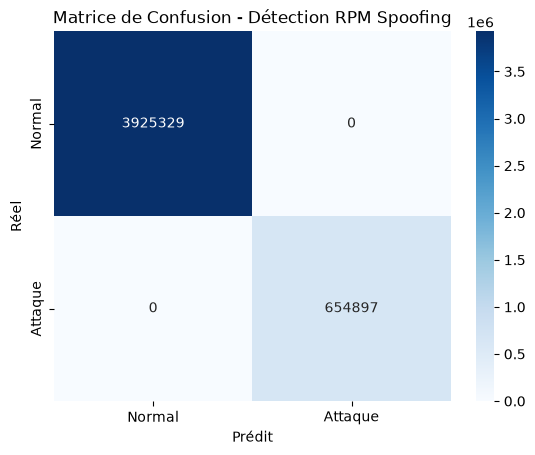

In [16]:
# Règle de détection RPM Spoofing
def detect_rpm_spoofing(row):
    if row['ID'] == '0316' and row['D0'] == '45':
        return 'T'
    return 'R'

df_rpm['Prediction'] = df_rpm.apply(detect_rpm_spoofing, axis=1)

# Nettoyer
df_rpm['Flag'] = df_rpm['Flag'].astype(str).str.strip()
df_rpm['Prediction'] = df_rpm['Prediction'].astype(str).str.strip()
df_rpm = df_rpm[df_rpm['Flag'].isin(['R', 'T'])]

# Évaluer
print("Rapport de classification:")
print(classification_report(df_rpm['Flag'], df_rpm['Prediction']))

# Matrice de confusion
cm = confusion_matrix(df_rpm['Flag'], df_rpm['Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection RPM Spoofing')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

In [17]:
# Charger le dataset Gear
df_gear = pd.read_csv('gear_dataset.csv', header=None, on_bad_lines='skip')
df_gear.columns = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

# Nettoyer
df_gear = df_gear.dropna(subset=['Flag'])
df_gear['Flag'] = df_gear['Flag'].str.strip()

# Distribution
print("Shape:", df_gear.shape)
print("\nDistribution des flags:")
print(df_gear['Flag'].value_counts())

# Top IDs dans attaques
print("\nTop 10 IDs dans les attaques Gear:")
print(df_gear[df_gear['Flag'] == 'T']['ID'].value_counts().head(10))

/var/folders/x3/q795jdbj25z2m082hx6tj3y00000gn/T/ipykernel_91792/678269552.py:2: DtypeWarning: Columns (0: 3, 1: 4, 2: 6, 3: 8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gear = pd.read_csv('gear_dataset.csv', header=None, on_bad_lines='skip')


Shape: (3067439, 12)

Distribution des flags:
Flag
R     2530104
T      523629
00       6326
60       3021
74        264
       ...   
22          2
1f          1
21          1
1e          1
23          1
Name: count, Length: 78, dtype: int64

Top 10 IDs dans les attaques Gear:
ID
043f    523629
Name: count, dtype: int64


In [18]:
# Comparer D0 entre normal et attaque pour l'ID 043f
normal_043f = df_gear[(df_gear['Flag'] == 'R') & (df_gear['ID'] == '043f')]['D0']
attaque_043f = df_gear[(df_gear['Flag'] == 'T') & (df_gear['ID'] == '043f')]['D0']

print("Valeurs D0 normales (ID 043f):")
print(normal_043f.value_counts().head(10))

print("\nValeurs D0 dans attaques (ID 043f):")
print(attaque_043f.value_counts().head(10))

Valeurs D0 normales (ID 043f):
D0
10    137759
Name: count, dtype: int64

Valeurs D0 dans attaques (ID 043f):
D0
01    523629
Name: count, dtype: int64


Rapport de classification:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00   2530104
           T       1.00      1.00      1.00    523629

    accuracy                           1.00   3053733
   macro avg       1.00      1.00      1.00   3053733
weighted avg       1.00      1.00      1.00   3053733



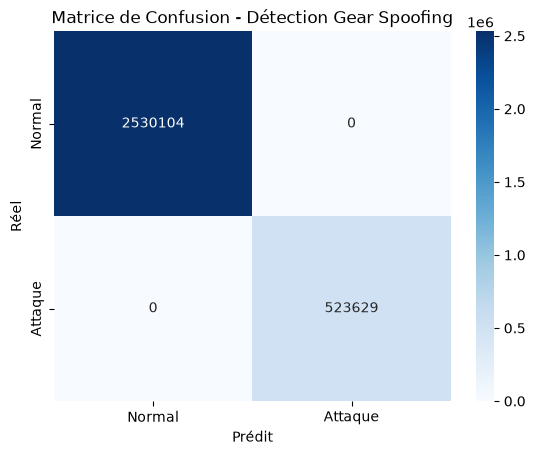

In [19]:
# Règle de détection Gear Spoofing
def detect_gear_spoofing(row):
    if row['ID'] == '043f' and row['D0'] == '01':
        return 'T'
    return 'R'

df_gear['Prediction'] = df_gear.apply(detect_gear_spoofing, axis=1)

# Nettoyer - garder seulement R et T
df_gear['Flag'] = df_gear['Flag'].astype(str).str.strip()
df_gear = df_gear[df_gear['Flag'].isin(['R', 'T'])]
df_gear['Prediction'] = df_gear['Prediction'].astype(str).str.strip()

# Évaluer
print("Rapport de classification:")
print(classification_report(df_gear['Flag'], df_gear['Prediction']))

# Matrice de confusion
cm = confusion_matrix(df_gear['Flag'], df_gear['Prediction'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection Gear Spoofing')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

In [20]:
# Ajouter une colonne pour identifier le type d'attaque
df_dos['Attack_Type'] = 'DoS'
df_fuzzy['Attack_Type'] = 'Fuzzy'
df_rpm['Attack_Type'] = 'RPM'
df_gear['Attack_Type'] = 'Gear'

# Combiner tous les datasets
df_all = pd.concat([df_dos, df_fuzzy, df_rpm, df_gear], ignore_index=True)

# Nettoyer
df_all = df_all[df_all['Flag'].isin(['R', 'T'])]
df_all['Flag'] = df_all['Flag'].astype(str).str.strip()

print("Shape total:", df_all.shape)
print("\nDistribution globale:")
print(df_all['Flag'].value_counts())

Shape total: (13237647, 14)

Distribution globale:
Flag
R    11315515
T     1922132
Name: count, dtype: int64


In [21]:
# Convertir les IDs et données hex en nombres
df_sample = df_all.sample(n=500000, random_state=42)  # On prend un échantillon pour la rapidité

# Convertir ID en nombre
df_sample['ID_num'] = df_sample['ID'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)

# Convertir D0 en nombre
df_sample['D0_num'] = df_sample['D0'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)

# Convertir Flag en 0/1
df_sample['Label'] = df_sample['Flag'].apply(lambda x: 1 if x == 'T' else 0)

print("Distribution de l'échantillon:")
print(df_sample['Label'].value_counts())
print("\nAperçu:")
df_sample[['ID', 'ID_num', 'D0', 'D0_num', 'Label']].head()

Distribution de l'échantillon:
Label
0    427165
1     72835
Name: count, dtype: int64

Aperçu:


,ID,ID_num,D0,D0_num,Label
6845299,018f,399,fe,254,0
6024867,02a0,672,00,0,0
2644687,0130,304,12,18,0
9951134,0329,809,86,134,0
5975144,018f,399,fe,254,0


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Features et label
X = df_sample[['ID_num', 'D0_num', 'DLC']]
y = df_sample['Label']

# Convertir DLC en nombre
X = X.copy()
X['DLC'] = pd.to_numeric(X['DLC'], errors='coerce').fillna(0)

# Split train/test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Entraîner le modèle
print("\nEntraînement en cours...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Entraînement terminé !")

Task was destroyed but it is pending!
task: <Task pending name='Task-145' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task finished name='Task-146' coro=<Kernel.shell_main() done, defined at /Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('9ba3f8fa-754b-4e36-b080-bc5058755317')> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task exception was never retrieved
future: <Task finished name='Task-146' coro=<Kernel.shell_main() done, defined at /Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> exception=KeyError('9ba3f8fa-754b-4e36-b080-bc5058755317')>
Traceback (most recent call last):
  File "/Users/hatimziadboutaghras/stage_canb

Train size: (400000, 3)
Test size: (100000, 3)

Entraînement en cours...
Entraînement terminé !


Rapport de classification - Random Forest:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85342
     Attaque       1.00      1.00      1.00     14658

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



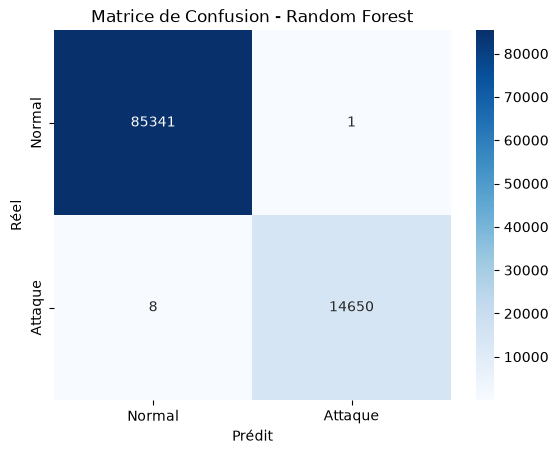

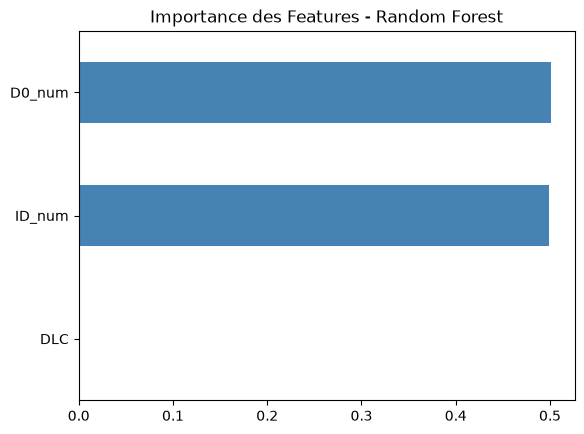

In [23]:
# Prédictions
y_pred = model.predict(X_test)

# Rapport
print("Rapport de classification - Random Forest:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attaque']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

# Importance des features
feature_importance = pd.Series(model.feature_importances_, index=['ID_num', 'D0_num', 'DLC'])
feature_importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Importance des Features - Random Forest')
plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import time

# Définir les modèles à comparer
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Entraînement : {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    acc = (y_pred == y_test).mean()
    results[name] = {'accuracy': acc, 'time': train_time}
    print(f"✅ {name} — Accuracy: {acc:.4f} — Temps: {train_time:.2f}s")

print("\nTerminé !")

Entraînement : Decision Tree...
✅ Decision Tree — Accuracy: 0.9999 — Temps: 0.22s
Entraînement : Random Forest...
✅ Random Forest — Accuracy: 0.9999 — Temps: 2.80s
Entraînement : KNN...
✅ KNN — Accuracy: 0.9997 — Temps: 0.10s
Entraînement : Logistic Regression...
✅ Logistic Regression — Accuracy: 0.8534 — Temps: 0.37s

Terminé !


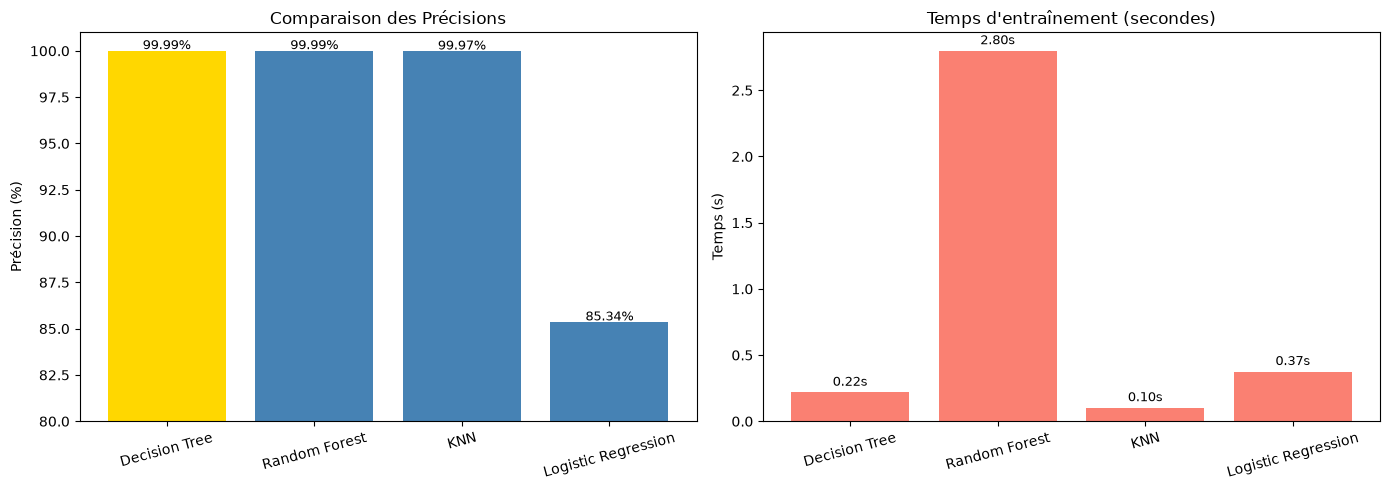

In [25]:
# Visualiser la comparaison
names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in names]
times = [results[m]['time'] for m in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Précision
colors = ['gold' if a == max(accuracies) else 'steelblue' for a in accuracies]
ax1.bar(names, accuracies, color=colors)
ax1.set_title('Comparaison des Précisions')
ax1.set_ylabel('Précision (%)')
ax1.set_ylim([80, 101])
ax1.tick_params(axis='x', rotation=15)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)

# Temps
ax2.bar(names, times, color='salmon')
ax2.set_title('Temps d\'entraînement (secondes)')
ax2.set_ylabel('Temps (s)')
ax2.tick_params(axis='x', rotation=15)
for i, v in enumerate(times):
    ax2.text(i, v + 0.05, f'{v:.2f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
import random

# Simuler un IDS en temps réel
print("=" * 55)
print("   🛡️  IDS - Intrusion Detection System CAN Bus")
print("=" * 55)
print("Surveillance du réseau CAN en cours...\n")

# Prendre 20 trames aléatoires du dataset
sample_stream = df_all.sample(n=20, random_state=99).reset_index(drop=True)

alerts = 0

for i, row in sample_stream.iterrows():
    # Convertir pour la prédiction
    try:
        id_num = int(str(row['ID']), 16)
        d0_num = int(str(row['D0']), 16)
        dlc = int(str(row['DLC']))
    except:
        continue
    
    # Prédiction
    prediction = model.predict([[id_num, d0_num, dlc]])[0]
    status = "🚨 ATTAQUE DÉTECTÉE" if prediction == 1 else "✅ Normal"
    
    if prediction == 1:
        alerts += 1
    
    print(f"Trame {i+1:02d} | ID: {row['ID']} | D0: {row['D0']} | {status}")

print("\n" + "=" * 55)
print(f"📊 Résumé : {20} trames analysées | {alerts} alertes détectées")
print("=" * 55)

   🛡️  IDS - Intrusion Detection System CAN Bus
Surveillance du réseau CAN en cours...

Trame 01 | ID: 02a0 | D0: 00 | ✅ Normal
Trame 02 | ID: 0140 | D0: 00 | ✅ Normal
Trame 03 | ID: 04f0 | D0: 00 | ✅ Normal
Trame 04 | ID: 0000 | D0: 00 | ✅ Normal
Trame 05 | ID: 0153 | D0: 00 | ✅ Normal
Trame 06 | ID: 0545 | D0: d8 | ✅ Normal
Trame 07 | ID: 0545 | D0: d8 | ✅ Normal
Trame 08 | ID: 0260 | D0: 19 | ✅ Normal
Trame 09 | ID: 0130 | D0: 11 | ✅ Normal
Trame 10 | ID: 02c0 | D0: 15 | ✅ Normal
Trame 11 | ID: 0153 | D0: 00 | ✅ Normal
Trame 12 | ID: 0130 | D0: 15 | ✅ Normal
Trame 13 | ID: 04b1 | D0: 00 | ✅ Normal
Trame 14 | ID: 0545 | D0: d8 | ✅ Normal
Trame 15 | ID: 0316 | D0: 05 | ✅ Normal
Trame 16 | ID: 043f | D0: 00 | ✅ Normal
Trame 17 | ID: 0260 | D0: 19 | ✅ Normal
Trame 18 | ID: 0329 | D0: 40 | ✅ Normal
Trame 19 | ID: 00a1 | D0: 7f | ✅ Normal
Trame 20 | ID: 043f | D0: 00 | ✅ Normal

📊 Résumé : 20 trames analysées | 0 alertes détectées


/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/valid

In [27]:
# Simuler un flux mixte avec des attaques injectées
print("=" * 55)
print("   🛡️  IDS - Simulation avec attaques injectées")
print("=" * 55)
print("Surveillance du réseau CAN en cours...\n")

# Prendre 15 trames normales + 5 attaques
normales_stream = df_all[df_all['Flag'] == 'R'].sample(n=15, random_state=10)
attaques_stream = df_all[df_all['Flag'] == 'T'].sample(n=5, random_state=10)
stream = pd.concat([normales_stream, attaques_stream]).sample(frac=1, random_state=42).reset_index(drop=True)

alerts = 0

for i, row in stream.iterrows():
    try:
        id_num = int(str(row['ID']), 16)
        d0_num = int(str(row['D0']), 16)
        dlc = int(str(row['DLC']))
    except:
        continue

    prediction = model.predict([[id_num, d0_num, dlc]])[0]
    reel = "Attaque" if row['Flag'] == 'T' else "Normal"
    status = "🚨 ATTAQUE DÉTECTÉE" if prediction == 1 else "✅ Normal"

    if prediction == 1:
        alerts += 1

    print(f"Trame {i+1:02d} | ID: {row['ID']} | D0: {row['D0']} | Réel: {reel:7s} | {status}")

print("\n" + "=" * 55)
print(f"📊 Résumé : 20 trames | {alerts} attaques détectées")
print("=" * 55)

   🛡️  IDS - Simulation avec attaques injectées
Surveillance du réseau CAN en cours...

Trame 01 | ID: 0329 | D0: 87 | Réel: Normal  | ✅ Normal
Trame 02 | ID: 043f | D0: 01 | Réel: Attaque | ✅ Normal
Trame 03 | ID: 0000 | D0: 00 | Réel: Attaque | ✅ Normal
Trame 04 | ID: 043f | D0: 00 | Réel: Normal  | ✅ Normal
Trame 05 | ID: 0329 | D0: 0c | Réel: Normal  | ✅ Normal
Trame 06 | ID: 0440 | D0: ff | Réel: Normal  | ✅ Normal
Trame 07 | ID: 0545 | D0: d8 | Réel: Normal  | ✅ Normal
Trame 08 | ID: 018f | D0: fe | Réel: Normal  | ✅ Normal
Trame 09 | ID: 0000 | D0: 00 | Réel: Attaque | ✅ Normal
Trame 10 | ID: 0316 | D0: 45 | Réel: Attaque | ✅ Normal
Trame 11 | ID: 0260 | D0: 1a | Réel: Normal  | ✅ Normal
Trame 12 | ID: 0153 | D0: 00 | Réel: Normal  | ✅ Normal
Trame 13 | ID: 0131 | D0: 05 | Réel: Normal  | ✅ Normal
Trame 14 | ID: 043f | D0: 01 | Réel: Attaque | ✅ Normal
Trame 15 | ID: 01f1 | D0: 08 | Réel: Normal  | ✅ Normal
Trame 16 | ID: 0130 | D0: 1b | Réel: Normal  | ✅ Normal
Trame 17 | ID: 0

/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/utils/valid

In [28]:
# Utiliser explicitement le Random Forest
rf_model = models['Random Forest']

print("=" * 55)
print("   🛡️  IDS - Simulation avec attaques injectées")
print("=" * 55)
print("Surveillance du réseau CAN en cours...\n")

alerts = 0

for i, row in stream.iterrows():
    try:
        id_num = int(str(row['ID']), 16)
        d0_num = int(str(row['D0']), 16)
        dlc = int(str(row['DLC']))
    except:
        continue

    features = pd.DataFrame([[id_num, d0_num, dlc]], columns=['ID_num', 'D0_num', 'DLC'])
    prediction = rf_model.predict(features)[0]
    reel = "Attaque" if row['Flag'] == 'T' else "Normal"
    status = "🚨 ATTAQUE DÉTECTÉE" if prediction == 1 else "✅ Normal"

    if prediction == 1:
        alerts += 1

    print(f"Trame {i+1:02d} | ID: {row['ID']} | D0: {row['D0']} | Réel: {reel:7s} | {status}")

print("\n" + "=" * 55)
print(f"📊 Résumé : 20 trames | {alerts} attaques détectées")
print("=" * 55)

   🛡️  IDS - Simulation avec attaques injectées
Surveillance du réseau CAN en cours...

Trame 01 | ID: 0329 | D0: 87 | Réel: Normal  | ✅ Normal
Trame 02 | ID: 043f | D0: 01 | Réel: Attaque | 🚨 ATTAQUE DÉTECTÉE
Trame 03 | ID: 0000 | D0: 00 | Réel: Attaque | 🚨 ATTAQUE DÉTECTÉE
Trame 04 | ID: 043f | D0: 00 | Réel: Normal  | ✅ Normal
Trame 05 | ID: 0329 | D0: 0c | Réel: Normal  | ✅ Normal
Trame 06 | ID: 0440 | D0: ff | Réel: Normal  | ✅ Normal
Trame 07 | ID: 0545 | D0: d8 | Réel: Normal  | ✅ Normal
Trame 08 | ID: 018f | D0: fe | Réel: Normal  | ✅ Normal
Trame 09 | ID: 0000 | D0: 00 | Réel: Attaque | 🚨 ATTAQUE DÉTECTÉE
Trame 10 | ID: 0316 | D0: 45 | Réel: Attaque | 🚨 ATTAQUE DÉTECTÉE
Trame 11 | ID: 0260 | D0: 1a | Réel: Normal  | ✅ Normal
Trame 12 | ID: 0153 | D0: 00 | Réel: Normal  | ✅ Normal
Trame 13 | ID: 0131 | D0: 05 | Réel: Normal  | ✅ Normal
Trame 14 | ID: 043f | D0: 01 | Réel: Attaque | 🚨 ATTAQUE DÉTECTÉE
Trame 15 | ID: 01f1 | D0: 08 | Réel: Normal  | ✅ Normal
Trame 16 | ID: 0130 | 

In [29]:
# IDS sur tout le dataset
print("=" * 55)
print("   🛡️  IDS - Analyse complète du dataset")
print("=" * 55)
print("Analyse en cours...\n")

# Préparer toutes les données
df_ids = df_all.copy()
df_ids = df_ids[df_ids['Flag'].isin(['R', 'T'])]

df_ids['ID_num'] = df_ids['ID'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)
df_ids['D0_num'] = df_ids['D0'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)
df_ids['DLC'] = pd.to_numeric(df_ids['DLC'], errors='coerce').fillna(0)

X_ids = df_ids[['ID_num', 'D0_num', 'DLC']]

print(f"Nombre total de trames à analyser : {len(df_ids):,}")
print("Prédiction en cours (peut prendre quelques minutes)...")

# Prédictions
df_ids['Prediction'] = rf_model.predict(X_ids)
df_ids['Prediction_label'] = df_ids['Prediction'].apply(lambda x: 'T' if x == 1 else 'R')

# Résumé
total = len(df_ids)
attaques = df_ids['Prediction'].sum()
normales = total - attaques

print(f"\n{'=' * 55}")
print(f"📊 RAPPORT IDS COMPLET")
print(f"{'=' * 55}")
print(f"Total trames analysées : {total:,}")
print(f"✅ Trames normales     : {normales:,}")
print(f"🚨 Attaques détectées  : {int(attaques):,}")
print(f"Taux d'attaques        : {attaques/total*100:.2f}%")
print(f"{'=' * 55}")

# Évaluation
print("\nRapport de classification complet:")
print(classification_report(df_ids['Flag'], df_ids['Prediction_label']))

   🛡️  IDS - Analyse complète du dataset
Analyse en cours...

Nombre total de trames à analyser : 13,237,647
Prédiction en cours (peut prendre quelques minutes)...

📊 RAPPORT IDS COMPLET
Total trames analysées : 13,237,647
✅ Trames normales     : 11,316,339
🚨 Attaques détectées  : 1,921,308
Taux d'attaques        : 14.51%

Rapport de classification complet:
              precision    recall  f1-score   support

           R       1.00      1.00      1.00  11315515
           T       1.00      1.00      1.00   1922132

    accuracy                           1.00  13237647
   macro avg       1.00      1.00      1.00  13237647
weighted avg       1.00      1.00      1.00  13237647



In [30]:
# Ajouter le type d'attaque comme label
df_all['Label_type'] = 'Normal'
df_all.loc[(df_all['Flag'] == 'T') & (df_all['Attack_Type'] == 'DoS'), 'Label_type'] = 'DoS'
df_all.loc[(df_all['Flag'] == 'T') & (df_all['Attack_Type'] == 'Fuzzy'), 'Label_type'] = 'Fuzzy'
df_all.loc[(df_all['Flag'] == 'T') & (df_all['Attack_Type'] == 'RPM'), 'Label_type'] = 'RPM Spoofing'
df_all.loc[(df_all['Flag'] == 'T') & (df_all['Attack_Type'] == 'Gear'), 'Label_type'] = 'Gear Spoofing'

# Distribution
print("Distribution des types:")
print(df_all['Label_type'].value_counts())

Distribution des types:
Label_type
Normal           11315515
RPM Spoofing       654897
DoS                587521
Gear Spoofing      523629
Fuzzy              156085
Name: count, dtype: int64


In [31]:
# Préparer les données
df_multi = df_all.copy()
df_multi['ID_num'] = df_multi['ID'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)
df_multi['D0_num'] = df_multi['D0'].apply(lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0)
df_multi['DLC'] = pd.to_numeric(df_multi['DLC'], errors='coerce').fillna(0)

# Échantillon pour la rapidité
df_multi_sample = df_multi.sample(n=500000, random_state=42)

X_multi = df_multi_sample[['ID_num', 'D0_num', 'DLC']]
y_multi = df_multi_sample['Label_type']

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Entraîner
print("Entraînement du classifieur multiclasse...")
rf_multi = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_multi.fit(X_train_m, y_train_m)
print("Terminé !")

# Évaluer
y_pred_m = rf_multi.predict(X_test_m)
print("\nRapport de classification multiclasse:")
print(classification_report(y_test_m, y_pred_m))

Entraînement du classifieur multiclasse...
Terminé !

Rapport de classification multiclasse:
               precision    recall  f1-score   support

          DoS       1.00      1.00      1.00      4462
        Fuzzy       1.00      0.99      0.99      1183
Gear Spoofing       1.00      1.00      1.00      4063
       Normal       1.00      1.00      1.00     85342
 RPM Spoofing       1.00      1.00      1.00      4950

     accuracy                           1.00    100000
    macro avg       1.00      1.00      1.00    100000
 weighted avg       1.00      1.00      1.00    100000



In [32]:
print("=" * 65)
print("   🛡️  IDS AVANCÉ - Type d'attaque + Score de confiance")
print("=" * 65)
print("Surveillance du réseau CAN en cours...\n")

alerts = 0

for i, row in stream.iterrows():
    try:
        id_num = int(str(row['ID']), 16)
        d0_num = int(str(row['D0']), 16)
        dlc = int(str(row['DLC']))
    except:
        continue

    features = pd.DataFrame([[id_num, d0_num, dlc]], columns=['ID_num', 'D0_num', 'DLC'])
    prediction = rf_multi.predict(features)[0]
    proba = rf_multi.predict_proba(features)[0]
    confidence = max(proba) * 100

    reel = row['Flag']
    if prediction == 'Normal':
        status = f"✅ Normal ({confidence:.1f}%)"
    else:
        status = f"🚨 {prediction} ({confidence:.1f}%)"
        alerts += 1

    print(f"Trame {i+1:02d} | ID: {row['ID']} | D0: {row['D0']} | Réel: {'Attaque' if reel == 'T' else 'Normal':7s} | {status}")

print("\n" + "=" * 65)
print(f"📊 Résumé : 20 trames | {alerts} attaques détectées")
print("=" * 65)

   🛡️  IDS AVANCÉ - Type d'attaque + Score de confiance
Surveillance du réseau CAN en cours...

Trame 01 | ID: 0329 | D0: 87 | Réel: Normal  | ✅ Normal (100.0%)
Trame 02 | ID: 043f | D0: 01 | Réel: Attaque | 🚨 Gear Spoofing (100.0%)
Trame 03 | ID: 0000 | D0: 00 | Réel: Attaque | 🚨 DoS (100.0%)
Trame 04 | ID: 043f | D0: 00 | Réel: Normal  | ✅ Normal (100.0%)
Trame 05 | ID: 0329 | D0: 0c | Réel: Normal  | ✅ Normal (100.0%)
Trame 06 | ID: 0440 | D0: ff | Réel: Normal  | ✅ Normal (100.0%)
Trame 07 | ID: 0545 | D0: d8 | Réel: Normal  | ✅ Normal (100.0%)
Trame 08 | ID: 018f | D0: fe | Réel: Normal  | ✅ Normal (100.0%)
Trame 09 | ID: 0000 | D0: 00 | Réel: Attaque | 🚨 DoS (100.0%)
Trame 10 | ID: 0316 | D0: 45 | Réel: Attaque | 🚨 RPM Spoofing (100.0%)
Trame 11 | ID: 0260 | D0: 1a | Réel: Normal  | ✅ Normal (100.0%)
Trame 12 | ID: 0153 | D0: 00 | Réel: Normal  | ✅ Normal (100.0%)
Trame 13 | ID: 0131 | D0: 05 | Réel: Normal  | ✅ Normal (100.0%)
Trame 14 | ID: 043f | D0: 01 | Réel: Attaque | 🚨 Gea

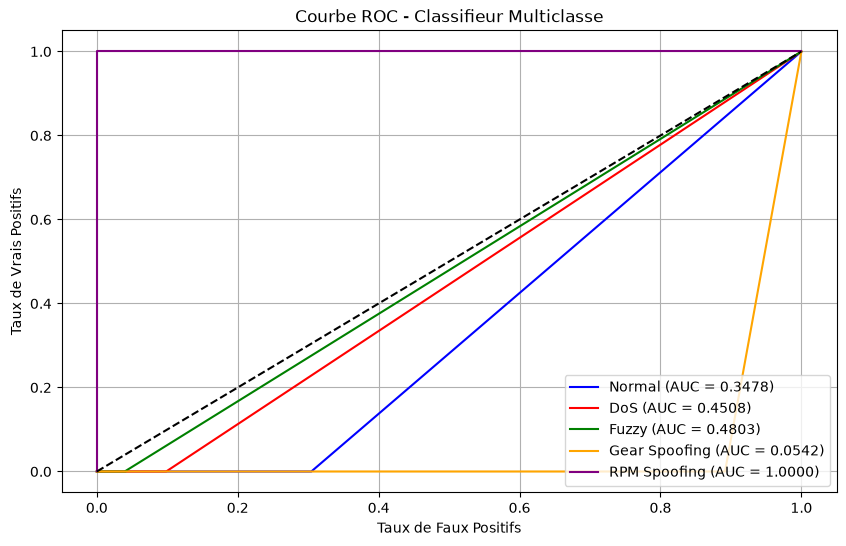

In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binariser les classes
classes = ['Normal', 'DoS', 'Fuzzy', 'Gear Spoofing', 'RPM Spoofing']
y_test_bin = label_binarize(y_test_m, classes=classes)
y_prob = rf_multi.predict_proba(X_test_m)

# Tracer la courbe ROC pour chaque classe
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Classifieur Multiclasse')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Ordre des classes: ['DoS' 'Fuzzy' 'Gear Spoofing' 'Normal' 'RPM Spoofing']


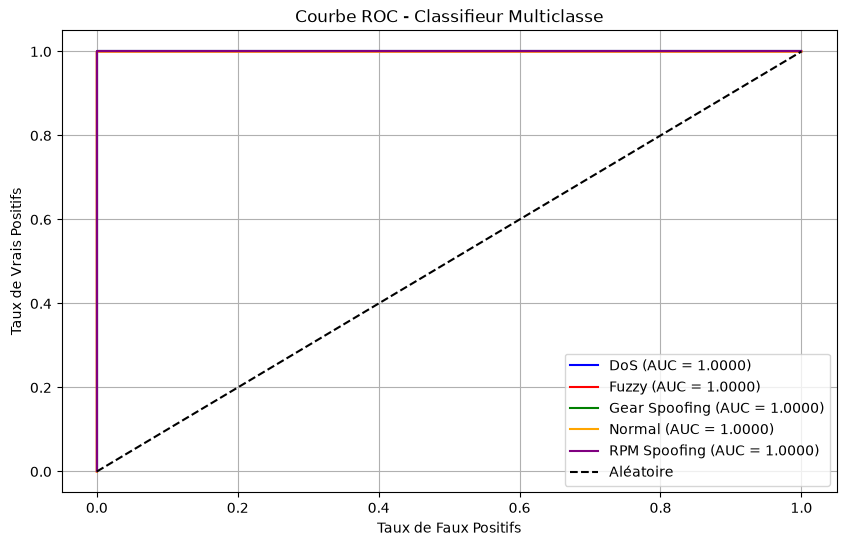

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Récupérer l'ordre exact des classes du modèle
classes = rf_multi.classes_
print("Ordre des classes:", classes)

y_test_bin = label_binarize(y_test_m, classes=classes)
y_prob = rf_multi.predict_proba(X_test_m)

# Tracer la courbe ROC
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Classifieur Multiclasse')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Ordre des classes: ['DoS' 'Fuzzy' 'Gear Spoofing' 'Normal' 'RPM Spoofing']


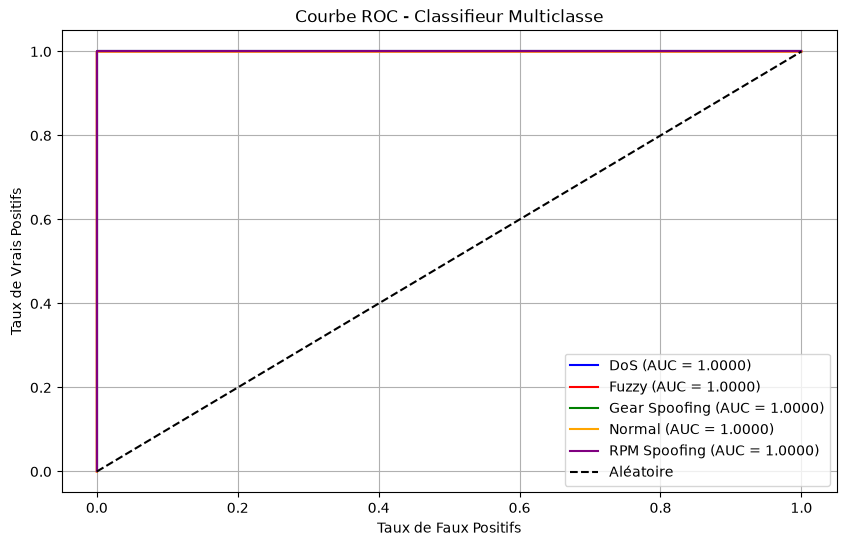

In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Récupérer l'ordre exact des classes du modèle
classes = rf_multi.classes_
print("Ordre des classes:", classes)

y_test_bin = label_binarize(y_test_m, classes=classes)
y_prob = rf_multi.predict_proba(X_test_m)

# Tracer la courbe ROC
plt.figure(figsize=(10, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Classifieur Multiclasse')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [36]:
# Convertir tous les octets D0-D7
df_multi2 = df_all.copy()

for col in ['ID', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']:
    df_multi2[f'{col}_num'] = df_multi2[col].apply(
        lambda x: int(str(x), 16) if str(x).strip() not in ['', 'nan'] else 0
    )

df_multi2['DLC'] = pd.to_numeric(df_multi2['DLC'], errors='coerce').fillna(0)

# Échantillon
df_multi2_sample = df_multi2.sample(n=500000, random_state=42)

features = ['ID_num', 'D0_num', 'D1_num', 'D2_num', 'D3_num', 
            'D4_num', 'D5_num', 'D6_num', 'D7_num', 'DLC']

X2 = df_multi2_sample[features]
y2 = df_multi2_sample['Label_type']

print("Features utilisées:", features)
print("Shape:", X2.shape)

Features utilisées: ['ID_num', 'D0_num', 'D1_num', 'D2_num', 'D3_num', 'D4_num', 'D5_num', 'D6_num', 'D7_num', 'DLC']
Shape: (500000, 10)


Entraînement avec tous les octets D0-D7...
Terminé !

Rapport de classification - 10 features:
               precision    recall  f1-score   support

          DoS       1.00      1.00      1.00      4462
        Fuzzy       1.00      1.00      1.00      1183
Gear Spoofing       1.00      1.00      1.00      4063
       Normal       1.00      1.00      1.00     85342
 RPM Spoofing       1.00      1.00      1.00      4950

     accuracy                           1.00    100000
    macro avg       1.00      1.00      1.00    100000
 weighted avg       1.00      1.00      1.00    100000



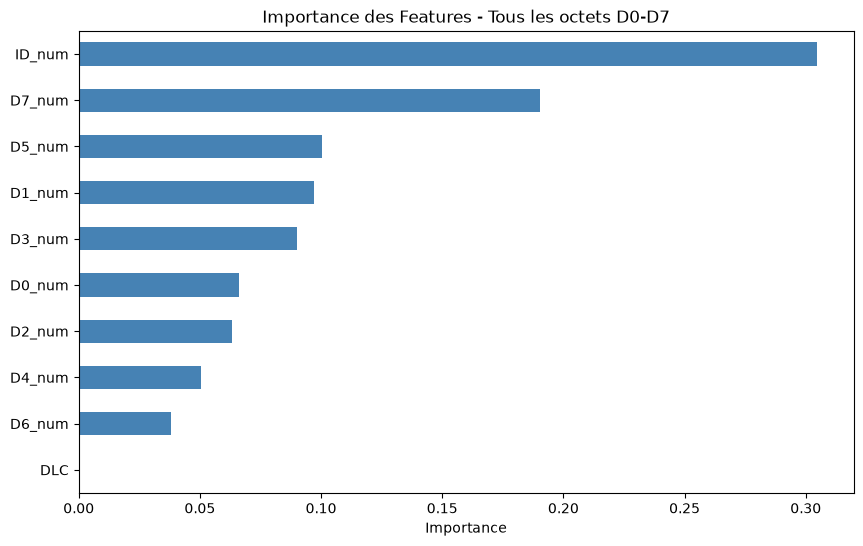

In [37]:
# Split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Entraîner
print("Entraînement avec tous les octets D0-D7...")
rf_full = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X2_train, y2_train)
print("Terminé !")

# Évaluer
y2_pred = rf_full.predict(X2_test)
print("\nRapport de classification - 10 features:")
print(classification_report(y2_test, y2_pred))

# Importance des features
feature_importance2 = pd.Series(rf_full.feature_importances_, index=features)
feature_importance2.sort_values().plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('Importance des Features - Tous les octets D0-D7')
plt.xlabel('Importance')
plt.show()

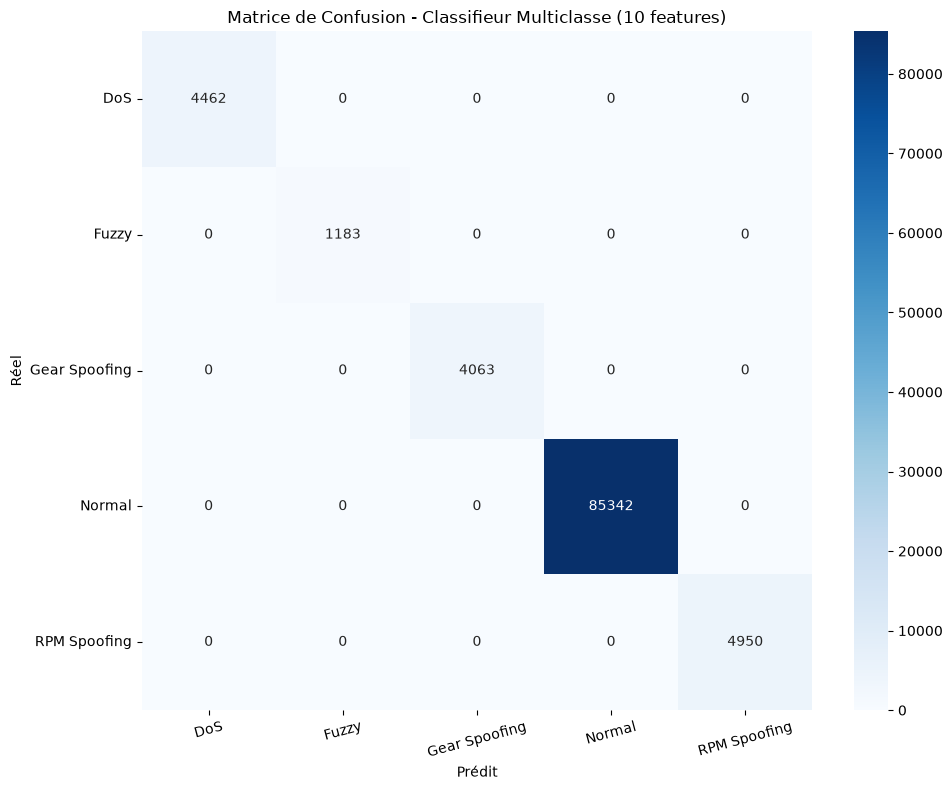

In [38]:
# Matrice de confusion multiclasse
from sklearn.metrics import ConfusionMatrixDisplay

cm_multi = confusion_matrix(y2_test, y2_pred, labels=rf_full.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_full.classes_,
            yticklabels=rf_full.classes_)
plt.title('Matrice de Confusion - Classifieur Multiclasse (10 features)')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

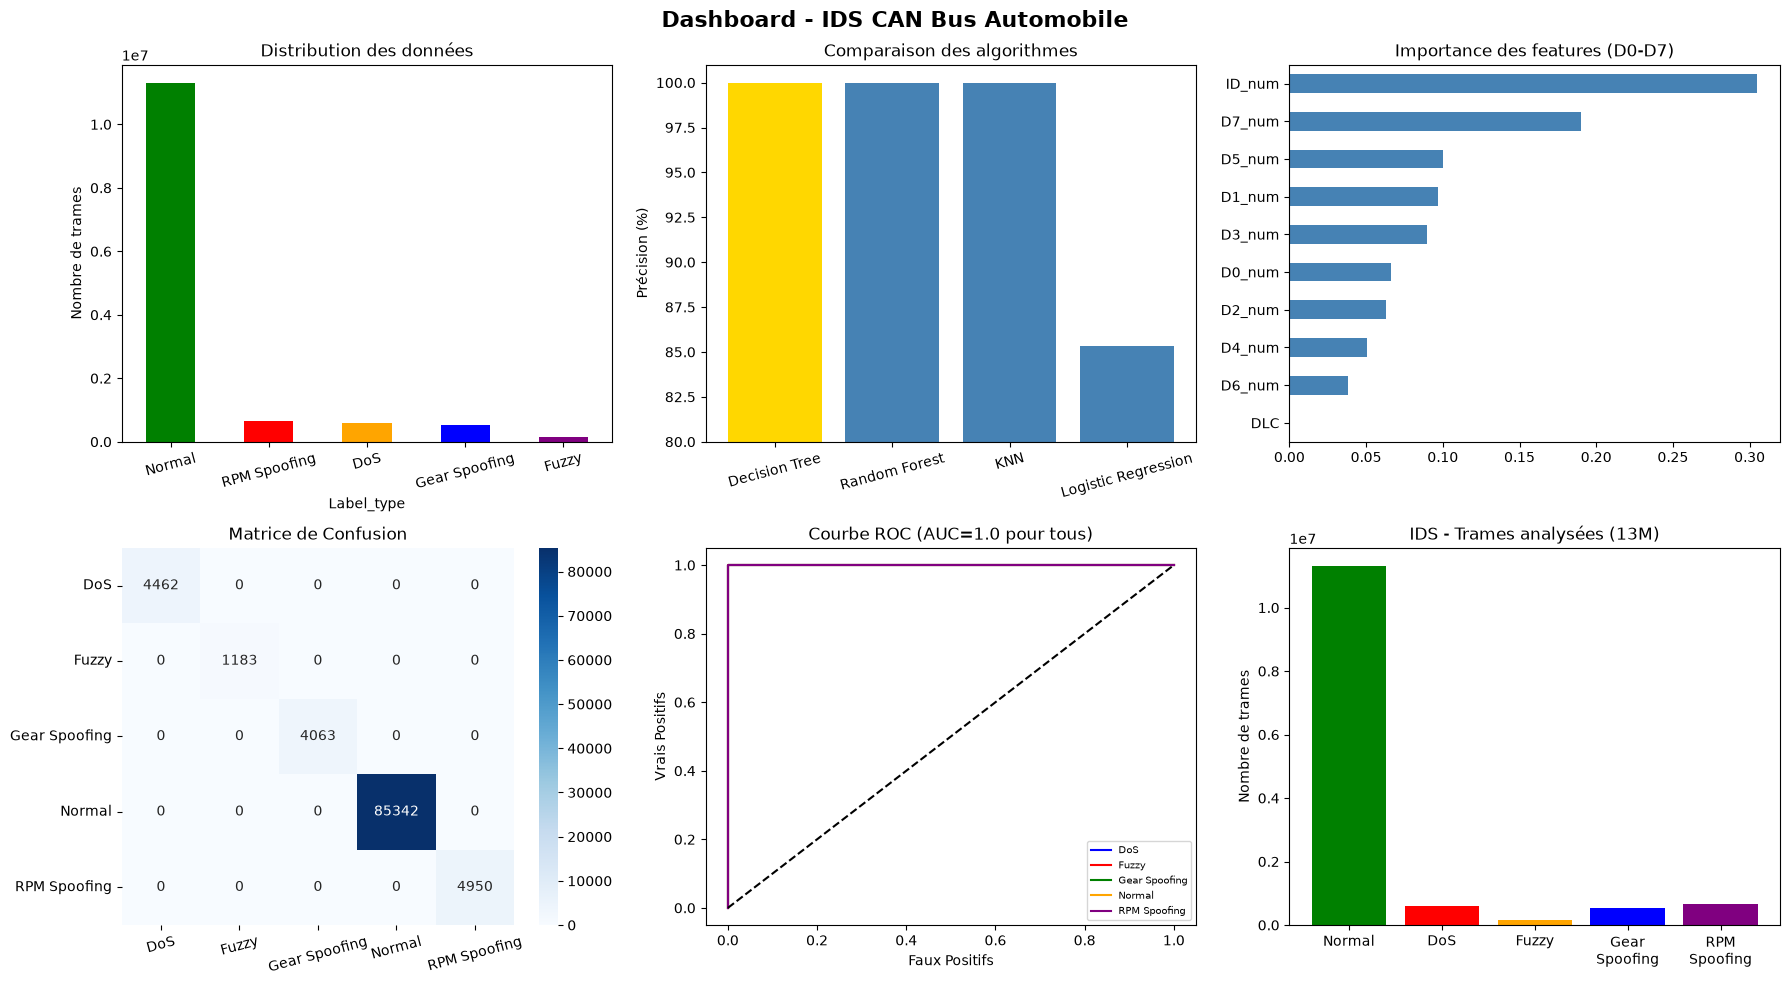

Dashboard sauvegardé !


In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Dashboard - IDS CAN Bus Automobile', fontsize=16, fontweight='bold')

# 1. Distribution globale des données
df_all['Label_type'].value_counts().plot(kind='bar', ax=axes[0,0], 
                                          color=['green','red','orange','blue','purple'])
axes[0,0].set_title('Distribution des données')
axes[0,0].set_ylabel('Nombre de trames')
axes[0,0].tick_params(axis='x', rotation=15)

# 2. Comparaison des algorithmes
names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in names]
axes[0,1].bar(names, accuracies, color=['gold','steelblue','steelblue','steelblue'])
axes[0,1].set_title('Comparaison des algorithmes')
axes[0,1].set_ylabel('Précision (%)')
axes[0,1].set_ylim([80, 101])
axes[0,1].tick_params(axis='x', rotation=15)

# 3. Importance des features
feature_importance2.sort_values().plot(kind='barh', ax=axes[0,2], color='steelblue')
axes[0,2].set_title('Importance des features (D0-D7)')

# 4. Matrice de confusion multiclasse
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_full.classes_,
            yticklabels=rf_full.classes_,
            ax=axes[1,0])
axes[1,0].set_title('Matrice de Confusion')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Courbe ROC
classes2 = rf_full.classes_
y2_test_bin = label_binarize(y2_test, classes=classes2)
y2_prob = rf_full.predict_proba(X2_test)
colors2 = ['blue', 'red', 'green', 'orange', 'purple']
for i, (cls, color) in enumerate(zip(classes2, colors2)):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_prob[:, i])
    axes[1,1].plot(fpr, tpr, color=color, label=f'{cls}')
axes[1,1].plot([0,1],[0,1],'k--')
axes[1,1].set_title('Courbe ROC (AUC=1.0 pour tous)')
axes[1,1].legend(fontsize=7)
axes[1,1].set_xlabel('Faux Positifs')
axes[1,1].set_ylabel('Vrais Positifs')

# 6. Résumé IDS
categories = ['Normal', 'DoS', 'Fuzzy', 'Gear\nSpoofing', 'RPM\nSpoofing']
values = [11315515, 587521, 156085, 523629, 654897]
colors3 = ['green', 'red', 'orange', 'blue', 'purple']
axes[1,2].bar(categories, values, color=colors3)
axes[1,2].set_title('IDS - Trames analysées (13M)')
axes[1,2].set_ylabel('Nombre de trames')

plt.tight_layout()
plt.savefig('dashboard_ids_canbus.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard sauvegardé !")

In [40]:
# Comparaison de l'impact des features
from sklearn.metrics import accuracy_score

print("Comparaison de l'impact des features...")

# Préparer les 3 configurations
configs = {
    'ID seulement': ['ID_num'],
    'ID + D0': ['ID_num', 'D0_num'],
    'ID + D0-D7 + DLC': ['ID_num', 'D0_num', 'D1_num', 'D2_num', 'D3_num', 
                          'D4_num', 'D5_num', 'D6_num', 'D7_num', 'DLC']
}

feature_results = {}

for config_name, feature_list in configs.items():
    print(f"\nEntraînement : {config_name}...")
    
    X_cfg = df_multi2_sample[feature_list]
    X_cfg_train, X_cfg_test, y_cfg_train, y_cfg_test = train_test_split(
        X_cfg, y2, test_size=0.2, random_state=42
    )
    
    rf_cfg = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_cfg.fit(X_cfg_train, y_cfg_train)
    y_cfg_pred = rf_cfg.predict(X_cfg_test)
    
    # Précision globale
    acc = accuracy_score(y_cfg_test, y_cfg_pred)
    
    # Précision par classe
    report = classification_report(y_cfg_test, y_cfg_pred, output_dict=True)
    fuzzy_f1 = report.get('Fuzzy', {}).get('f1-score', 0)
    
    feature_results[config_name] = {
        'accuracy': acc * 100,
        'fuzzy_f1': fuzzy_f1 * 100,
        'n_features': len(feature_list)
    }
    
    print(f"✅ Précision: {acc*100:.4f}% | Fuzzy F1: {fuzzy_f1*100:.2f}%")

print("\nTerminé !")

Comparaison de l'impact des features...

Entraînement : ID seulement...


/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hatimziadboutaghras/stage_canbus_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

✅ Précision: 91.2770% | Fuzzy F1: 98.76%

Entraînement : ID + D0...
✅ Précision: 99.9870% | Fuzzy F1: 99.45%

Entraînement : ID + D0-D7 + DLC...
✅ Précision: 100.0000% | Fuzzy F1: 100.00%

Terminé !


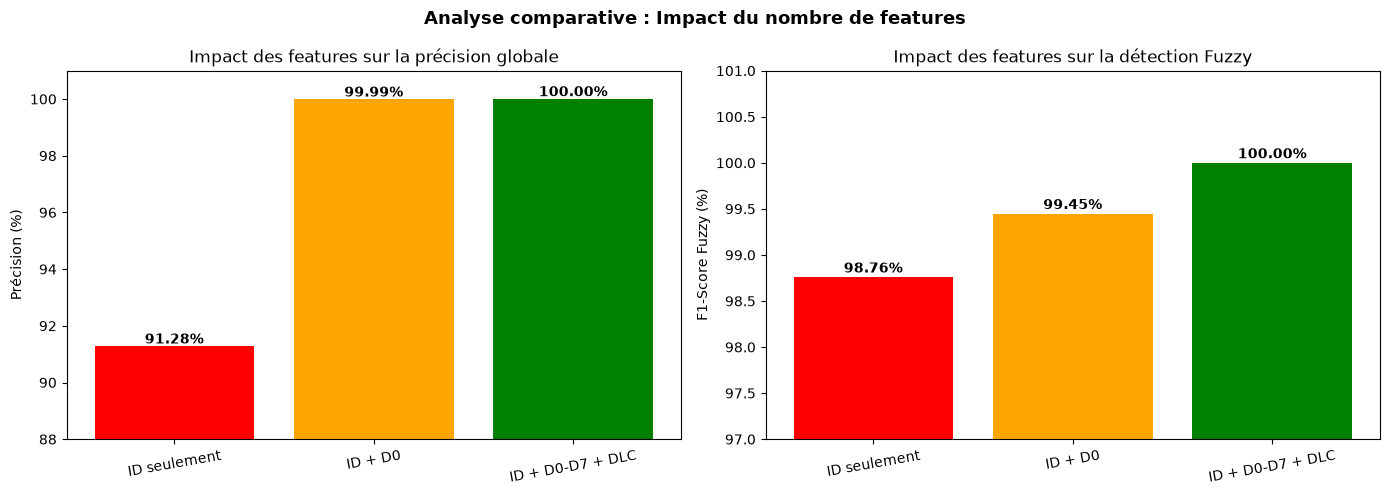

Graphique sauvegardé !


In [41]:
# Visualiser la comparaison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

configs_names = list(feature_results.keys())
accuracies = [feature_results[c]['accuracy'] for c in configs_names]
fuzzy_f1s = [feature_results[c]['fuzzy_f1'] for c in configs_names]
n_features = [feature_results[c]['n_features'] for c in configs_names]

# Précision globale
colors = ['red', 'orange', 'green']
bars = ax1.bar(configs_names, accuracies, color=colors)
ax1.set_title('Impact des features sur la précision globale')
ax1.set_ylabel('Précision (%)')
ax1.set_ylim([88, 101])
ax1.tick_params(axis='x', rotation=10)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Fuzzy F1
bars2 = ax2.bar(configs_names, fuzzy_f1s, color=colors)
ax2.set_title('Impact des features sur la détection Fuzzy')
ax2.set_ylabel('F1-Score Fuzzy (%)')
ax2.set_ylim([97, 101])
ax2.tick_params(axis='x', rotation=10)
for i, v in enumerate(fuzzy_f1s):
    ax2.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Analyse comparative : Impact du nombre de features', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

In [42]:
# Sauvegarder tous les graphiques importants
import matplotlib.pyplot as plt

# 1. Distribution DoS
df_dos['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (DoS)')
plt.savefig('fig1_distribution_dos.png', dpi=150, bbox_inches='tight')
plt.close()

# 2. Distribution Fuzzy
df_fuzzy['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (Fuzzy)')
plt.savefig('fig2_distribution_fuzzy.png', dpi=150, bbox_inches='tight')
plt.close()

print("Images sauvegardées !")

Images sauvegardées !


In [43]:
# Sauvegarder tous les graphiques manquants

# 3. Matrice de confusion DoS
cm_dos = confusion_matrix(df_dos['Flag'], df_dos['Prediction'])
sns.heatmap(cm_dos, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection DoS')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig('fig3_confusion_dos.png', dpi=150, bbox_inches='tight')
plt.close()

# 4. Comparaison algorithmes
names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in names]
colors = ['gold' if a == max(accuracies) else 'steelblue' for a in accuracies]
plt.bar(names, accuracies, color=colors)
plt.title('Comparaison des Précisions')
plt.ylabel('Précision (%)')
plt.ylim([80, 101])
plt.xticks(rotation=15)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=9)
plt.savefig('fig4_comparaison_algorithmes.png', dpi=150, bbox_inches='tight')
plt.close()

# 5. Importance des features
feature_importance2.sort_values().plot(kind='barh', color='steelblue', figsize=(10, 6))
plt.title('Importance des Features - Tous les octets D0-D7')
plt.xlabel('Importance')
plt.savefig('fig5_importance_features.png', dpi=150, bbox_inches='tight')
plt.close()

# 6. Matrice de confusion multiclasse
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_full.classes_,
            yticklabels=rf_full.classes_)
plt.title('Matrice de Confusion - Classifieur Multiclasse')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig6_confusion_multiclasse.png', dpi=150, bbox_inches='tight')
plt.close()

# 7. Courbe ROC
plt.figure(figsize=(10, 6))
classes2 = rf_full.classes_
y2_test_bin = label_binarize(y2_test, classes=classes2)
y2_prob = rf_full.predict_proba(X2_test)
colors2 = ['blue', 'red', 'green', 'orange', 'purple']
for i, (cls, color) in enumerate(zip(classes2, colors2)):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{cls} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Classifieur Multiclasse')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig('fig7_courbe_roc.png', dpi=150, bbox_inches='tight')
plt.close()

print("✅ Toutes les images sauvegardées !")

✅ Toutes les images sauvegardées !


In [44]:
# 8. Distribution RPM
df_rpm['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (RPM Spoofing)')
plt.xlabel('Flag')
plt.ylabel('Nombre de trames')
plt.savefig('fig8_distribution_rpm.png', dpi=150, bbox_inches='tight')
plt.close()

# 9. Distribution Gear
df_gear_clean = df_gear[df_gear['Flag'].isin(['R', 'T'])]
df_gear_clean['Flag'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution Normal vs Attaque (Gear Spoofing)')
plt.xlabel('Flag')
plt.ylabel('Nombre de trames')
plt.savefig('fig9_distribution_gear.png', dpi=150, bbox_inches='tight')
plt.close()

# 10. Matrice confusion Fuzzy
cm_fuzzy = confusion_matrix(df_fuzzy['Flag'], df_fuzzy['Prediction'])
sns.heatmap(cm_fuzzy, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection Fuzzy')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig('fig10_confusion_fuzzy.png', dpi=150, bbox_inches='tight')
plt.close()

# 11. Matrice confusion RPM
cm_rpm = confusion_matrix(df_rpm['Flag'], df_rpm['Prediction'])
sns.heatmap(cm_rpm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection RPM Spoofing')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig('fig11_confusion_rpm.png', dpi=150, bbox_inches='tight')
plt.close()

# 12. Matrice confusion Gear
cm_gear = confusion_matrix(df_gear['Flag'], df_gear['Prediction'])
sns.heatmap(cm_gear, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attaque'],
            yticklabels=['Normal', 'Attaque'])
plt.title('Matrice de Confusion - Détection Gear Spoofing')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.savefig('fig12_confusion_gear.png', dpi=150, bbox_inches='tight')
plt.close()

print("✅ Toutes les images sauvegardées !")

✅ Toutes les images sauvegardées !
